In [ ]:
!pip install fastf1

import os
import fastf1
import pandas as pd
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')


os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

print("Libraries imported successfully!")

import logging
logging.getLogger('fastf1').setLevel(logging.ERROR)


Driver map to get the name from the number

In [ ]:
DRIVER_MAP_2024 = {
    1:  ("VER", "Max Verstappen"),
    11: ("PER", "Sergio Pérez"),
    16: ("LEC", "Charles Leclerc"),
    55: ("SAI", "Carlos Sainz"),
    63: ("RUS", "George Russell"),
    44: ("HAM", "Lewis Hamilton"),
    4:  ("NOR", "Lando Norris"),
    81: ("PIA", "Oscar Piastri"),
    14: ("ALO", "Fernando Alonso"),
    18: ("STR", "Lance Stroll"),
    23: ("ALB", "Alex Albon"),
    2:  ("SAR", "Logan Sargeant"),
    20: ("MAG", "Kevin Magnussen"),
    27: ("HUL", "Nico Hülkenberg"),
    24: ("ZHO", "Guanyu Zhou"),
    77: ("BOT", "Valtteri Bottas"),
    10: ("GAS", "Pierre Gasly"),
    31: ("OCO", "Esteban Ocon"),
    22: ("TSU", "Yuki Tsunoda"),
    3:  ("RIC", "Daniel Ricciardo"),
}

def get_driver_info(session, driver):

    try:
        drv = session.get_driver(driver)
        return drv['Abbreviation'], drv['FullName']
    except:
        return "UNK", "Unknown"



In [ ]:
# Configuration
YEAR = 2024

N_RACES = 24  # Number of past races to analyze

# R for Race 
# Q for Qualifying 
# Sprint for Sprint
SESSION_TYPE = 'R'  


SPECIFIC_RACES = []
print(f"Configuration set: Analyzing {N_RACES} races from {YEAR}")

Get the race details for each race

In [ ]:
def get_race_list(year, n_races, specific_races=None):

    # getting the list of races
    schedule = fastf1.get_event_schedule(year)


    # Get last n completed races
    # Filter out future races and testing
    completed = schedule[schedule['EventFormat'] != 'testing']
    # You might want to add date filtering here for completed races
    races = completed.tail(n_races)
    
    return races[['EventName', 'Location', 'RoundNumber']]

# Get the race list
race_list = get_race_list(YEAR, N_RACES, SPECIFIC_RACES)
print(f"\nRaces to analyze:")
print(race_list)

Get the sector times of each driver 

In [ ]:
def get_driver_best_sectors(laps, driver):
    
    # get all of their race laps
    driver_laps = laps.pick_drivers(driver)
    
    # Filter for valid laps (laps where the driver has not breached track conditions)
    valid_laps = driver_laps.pick_accurate().pick_not_deleted()
    
    # sort them by laptime so we can use index 0 for fastest and we can get the average 
    valid_laps = valid_laps.sort_values('LapTime')
    
    if len(valid_laps) == 0:
        return None
    
    # Get best times
    best_sectors = {
        'Sector1': valid_laps['Sector1Time'].min(),
        'Sector2': valid_laps['Sector2Time'].min(),
        'Sector3': valid_laps['Sector3Time'].min()
    }
    
    return best_sectors

Overall fastest per sector

In [ ]:
def get_fastest_per_sector(year, race_name, session_type='R'):
    session = fastf1.get_session(year, race_name, session_type)
    session.load()

    results = {'race': race_name}

    for sec in [1, 2, 3]:
        sec_name = f"Sector{sec}" # sector 1, 2 or 3
        fastest_driver, fastest_time = None, None

        
        for d in session.drivers:
            best = get_driver_best_sectors(session.laps, d)
            if not best or pd.isna(best[sec_name]):
                continue
            

            t = best[sec_name]
            if fastest_time is None or t < fastest_time:
                fastest_time, fastest_driver = t, d

        
        results[sec_name] = {
            'driver': fastest_driver,
            'time': fastest_time
        }

    return results


In [ ]:
# Store results for all races
all_race_results = []

for idx, race in race_list.iterrows():
    race_name = race['EventName']
    result = get_fastest_per_sector(YEAR, race_name, SESSION_TYPE)
    
    if result:
        all_race_results.append(result)

print(f"\n Completed analysis for {len(all_race_results)} races")

In [ ]:
def display_sector_results(results):
    print("\n" + "="*70)
    print("FASTEST DRIVER PER SECTOR - RACE BY RACE")
    print("="*70)

    for result in results:
        print(f"\n {result['race']}")
        print("-" * 50)

        for sector in ['Sector1', 'Sector2', 'Sector3']:
            driver_raw = result[sector]['driver']
            time = result[sector]['time']

            # Normalize driver number
            try:
                driver_num = int(driver_raw)
            except:
                driver_num = None

            if driver_num and pd.notna(time):
                code, name = DRIVER_MAP_2024.get(driver_num, ("Unknown", "Unknown"))
                time_str = str(time).split()[-1]
                print(f"  {sector}: {name} ({code}) - {time_str}")
            else:
                print(f"  {sector}: No data")


# Display results
display_sector_results(all_race_results)

In [ ]:
def get_team_lineups(session):

    results = session.results
    
    team_lineups = {}
    for idx, driver in results.iterrows():
        team = driver['TeamName']
        driver_num = driver['DriverNumber']
        
        if team not in team_lineups:
            team_lineups[team] = []
        
        if driver_num not in team_lineups[team]:
            team_lineups[team].append(driver_num)
    
    # Only keep teams with exactly 2 drivers
    team_lineups = {team: drivers for team, drivers in team_lineups.items() 
                    if len(drivers) == 2}
    
    return team_lineups

In [ ]:
def analyze_team_head_to_head(year, race_name, session_type='R'):
    """
    Compare teammates sector by sector — with driver names + codes.
    """
    print(f"\nLoading {race_name} for team comparison...")

    try:
        # Load session
        session = fastf1.get_session(year, race_name, session_type)
        session.load()

        # Get team lineups
        team_lineups = get_team_lineups(session)

        race_comparison = {
            'race': race_name,
            'teams': {}
        }

        for team, drivers in team_lineups.items():
            if len(drivers) != 2:
                continue

            driver1, driver2 = drivers[0], drivers[1]

            # Sector bests
            d1_sectors = get_driver_best_sectors(session.laps, driver1)
            d2_sectors = get_driver_best_sectors(session.laps, driver2)

            if d1_sectors is None or d2_sectors is None:
                continue

            # Driver info
            d1_code, d1_name = get_driver_info(session, driver1)
            d2_code, d2_name = get_driver_info(session, driver2)

            team_result = {
                'driver1': {'num': driver1, 'code': d1_code, 'name': d1_name},
                'driver2': {'num': driver2, 'code': d2_code, 'name': d2_name},
                'sectors': {}
            }

            for sector in ['Sector1', 'Sector2', 'Sector3']:
                d1_time = d1_sectors[sector]
                d2_time = d2_sectors[sector]

                if pd.notna(d1_time) and pd.notna(d2_time):
                    winner = 'driver1' if d1_time < d2_time else 'driver2'
                    delta = abs(d1_time - d2_time)

                    team_result['sectors'][sector] = {
                        'winner': winner,
                        'winner_code': team_result[winner]['code'],
                        'winner_name': team_result[winner]['name'],
                        'd1_time': d1_time,
                        'd2_time': d2_time,
                        'delta': delta
                    }

            race_comparison['teams'][team] = team_result

        return race_comparison

    except Exception as e:
        print(f"Error loading {race_name}: {e}")
        return None


In [ ]:
# Store team comparisons for all races
all_team_comparisons = []

for idx, race in race_list.iterrows():
    race_name = race['EventName']
    comparison = analyze_team_head_to_head(YEAR, race_name, SESSION_TYPE)
    
    if comparison:
        all_team_comparisons.append(comparison)

print(f"\n✓ Completed team comparison for {len(all_team_comparisons)} races")

In [ ]:
def display_team_comparison_by_race(comparisons):
    """
    Simplified printout:
    Race Name
    Driver1 vs Driver2
    Section X - Winner - Delta
    """
    
    for comparison in comparisons:
        print(comparison['race'])
        
        # Get team (only one per comparison)
        team_data = list(comparison['teams'].values())[0]
        
        d1 = team_data['driver1']
        d2 = team_data['driver2']
        
        print(f"{d1['name']} ({d1['code']}) vs {d2['name']} ({d2['code']})")
        
        for sector, sector_data in team_data['sectors'].items():
            winner_key = sector_data['winner']
            
            if winner_key == "driver1":
                winner_name = d1['name']
            else:
                winner_name = d2['name']
            
            delta = str(sector_data['delta']).split()[-1]
            print(f"{sector} - {winner_name} - {delta}")
        
        print()  # Blank line between races


# Display results
display_team_comparison_by_race(all_team_comparisons)

In [ ]:
def aggregate_team_stats(comparisons):
    """
    Aggregate team performance across all races
    """
    team_stats = {}

    for comparison in comparisons:
        for team, data in comparison['teams'].items():

            d1 = data['driver1']
            d2 = data['driver2']

            if team not in team_stats:
                team_stats[team] = {
                    'driver1': d1,
                    'driver2': d2,
                    'Sector1': {'d1_wins': 0, 'd2_wins': 0, 'deltas': []},
                    'Sector2': {'d1_wins': 0, 'd2_wins': 0, 'deltas': []},
                    'Sector3': {'d1_wins': 0, 'd2_wins': 0, 'deltas': []}
                }

            for sector, sector_data in data['sectors'].items():
                # winner stored as 'driver1'/'driver2' and winner_code stored as code
                winner_key = sector_data.get('winner')            # 'driver1' or 'driver2'
                winner_code = sector_data.get('winner_code')

                # normalize winner_code (fallback to driver key lookup)
                if winner_code:
                    w_code = str(winner_code).strip().upper()
                else:
                    if winner_key == 'driver1':
                        w_code = str(d1['code']).strip().upper()
                    elif winner_key == 'driver2':
                        w_code = str(d2['code']).strip().upper()
                    else:
                        w_code = str(winner_key).strip().upper()

                d1_code = str(d1['code']).strip().upper()
                d2_code = str(d2['code']).strip().upper()
                delta = sector_data.get('delta')

                if w_code == d1_code:
                    team_stats[team][sector]['d1_wins'] += 1
                elif w_code == d2_code:
                    team_stats[team][sector]['d2_wins'] += 1
                else:
                    print("WARNING: Winner does not match either driver for", team, winner_key, d1_code, d2_code)

                if delta is not None:
                    team_stats[team][sector]['deltas'].append(delta)

    return team_stats


In [ ]:
def display_aggregated_stats(team_stats, n_races):
    """
    Display total head-to-head results:
    Team
    Driver1 vs Driver2
    Driver1 beats Driver2 X–Y
    """
    print(f"\nAGGREGATED TEAM STATISTICS (Last {n_races} Races)\n")
    
    for team, stats in team_stats.items():
        d1 = stats["driver1"]
        d2 = stats["driver2"]

        d1_name = d1["name"]
        d2_name = d2["name"]
        
        total_d1 = sum(stats[sector]["d1_wins"] for sector in ["Sector1", "Sector2", "Sector3"])
        total_d2 = sum(stats[sector]["d2_wins"] for sector in ["Sector1", "Sector2", "Sector3"])
        
        print(team)
        print(f"{d1_name} vs {d2_name}")
        
        if total_d1 > total_d2:
            print(f"{d1_name} beats {d2_name} {total_d1}-{total_d2} at a {round((total_d1 / (total_d2 + total_d1)) * 100, 2)}% win rate")
        elif total_d2 > total_d1:
            print(f"{d2_name} beats {d1_name} {total_d2}-{total_d1} at a {round((total_d2 / (total_d1 + total_d2) * 100), 2)}% win rate")
        else:
            print(f"{d1_name} and {d2_name} tied {total_d1}-{total_d2} at a {round((total_d1 / (total_d2 + total_d1)) * 100, 2)}% win rate")
        
        print()



# Display aggregated results
team_stats = aggregate_team_stats(all_team_comparisons)
display_aggregated_stats(team_stats, N_RACES)

core           INFO 	Loading data for Bahrain Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '11', '55', '16', '63', '4', '44', '81', '14', '18', '24', '20', '3', '22', '23', '27', '31', '10', '77', '2']
core           INFO 	Loading data for Saudi Arabian Grand Prix

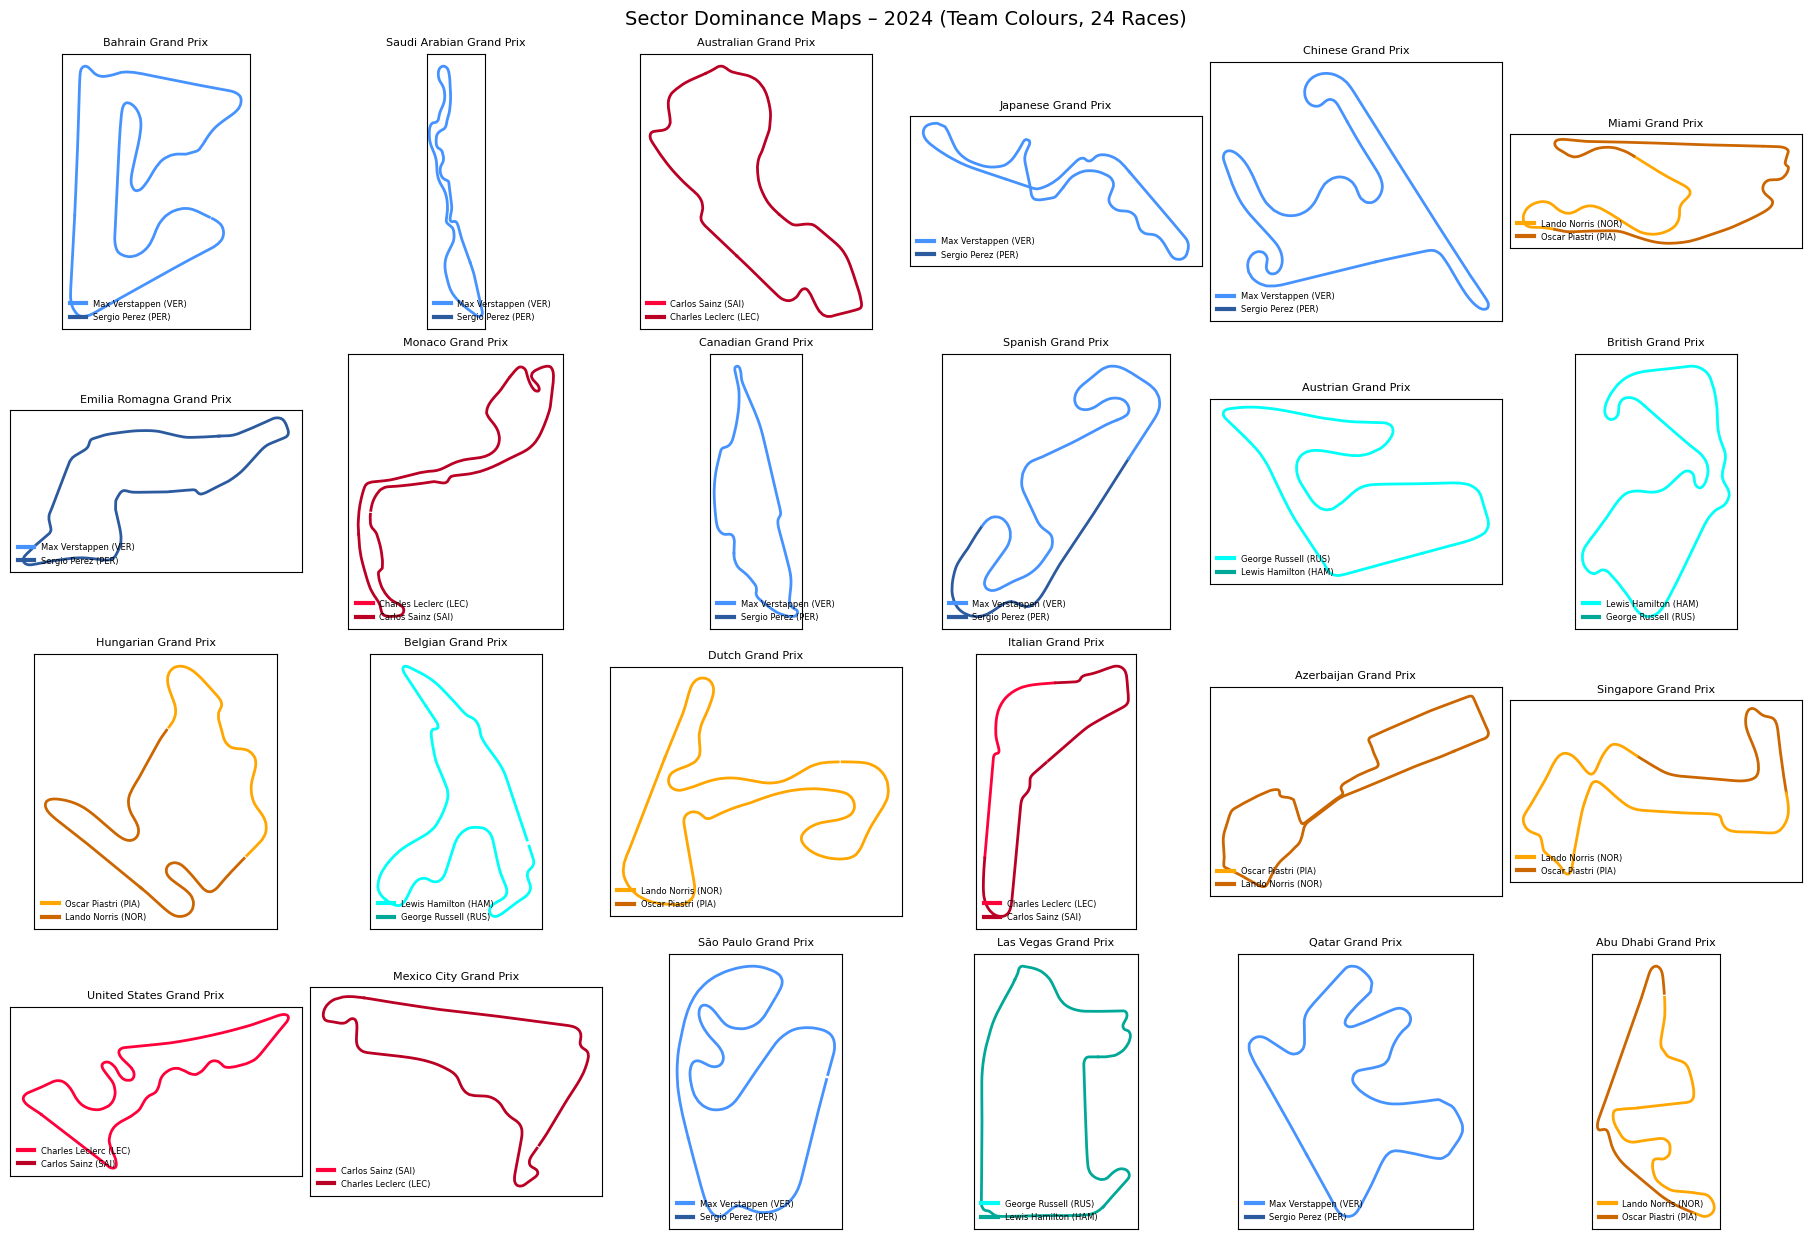

In [57]:
import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb, to_hex

# -------------------------------------------------------------------
#  FastF1 cache + plotting style
# -------------------------------------------------------------------
fastf1.Cache.enable_cache("cache")  # change path if you want
fastf1.plotting.setup_mpl(misc_mpl_mods=False)

# -------------------------------------------------------------------
#  Team base colours (2024-ish)
# -------------------------------------------------------------------
TEAM_COLORS = {
    "Red Bull Racing": "#3671C6",
    "Ferrari": "#E8002D",
    "Mercedes": "#00D2BE",
    "McLaren": "#FF8000",
    "Aston Martin": "#229971",
    "Kick Sauber": "#00E701",     # adjust if you have better
    "Haas F1 Team": "#B6BABD",
    "RB": "#0018A8",
    "Williams": "#005AFF",
    "Alpine": "#FF87BC",
}

DEFAULT_TEAM_COLOR = "#888888"


# -------------------------------------------------------------------
#  Helper: lighten/darken a hex colour
# -------------------------------------------------------------------
def adjust_lightness(color_hex: str, factor: float) -> str:
    """
    Adjust lightness of a hex color.
    factor > 1.0 -> lighter
    factor < 1.0 -> darker
    """
    r, g, b = to_rgb(color_hex)
    r = min(1.0, max(0.0, r * factor))
    g = min(1.0, max(0.0, g * factor))
    b = min(1.0, max(0.0, b * factor))
    return to_hex((r, g, b))


# -------------------------------------------------------------------
#  Core plotting function
# -------------------------------------------------------------------
def plot_sector_dominance_grid(all_team_comparisons, year=2024):
    """
    Plot a 6x4 grid of circuit maps (24 races).
    Each subplot: one race, one team battle.
    Track is split into 3 sectors and coloured by the driver who wins that sector.
    Uses team colours, with lighter/darker shades for driver1/driver2.
    """
    n_races = min(24, len(all_team_comparisons))
    n_rows, n_cols = 4, 6

    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(18, 12),
        constrained_layout=True
    )

    # Flatten axes for easy indexing
    axes_flat = axes.flatten()

    for round_number, (comparison, ax) in enumerate(
        zip(all_team_comparisons[:n_races], axes_flat[:n_races]),
        start=1
    ):
        race_name = comparison["race"]

        # ---- Team + driver info ----
        team_name, team_data = list(comparison["teams"].items())[0]
        d1 = team_data["driver1"]  # dict with num, code, name
        d2 = team_data["driver2"]

        d1_code = d1["code"]
        d2_code = d2["code"]

        base_color = TEAM_COLORS.get(team_name, DEFAULT_TEAM_COLOR)
        d1_color = adjust_lightness(base_color, 1.3)  # lighter
        d2_color = adjust_lightness(base_color, 0.8)  # darker

        # ---- Sector winners ("driver1"/"driver2") ----
        sectors = team_data["sectors"]
        s1_winner_key = sectors["Sector1"]["winner"]
        s2_winner_key = sectors["Sector2"]["winner"]
        s3_winner_key = sectors["Sector3"]["winner"]

        # Map "driver1"/"driver2" -> actual colours
        def winner_color(winner_key: str) -> str:
            return d1_color if winner_key == "driver1" else d2_color

        # ---- Load session via round number ----
        try:
            session = fastf1.get_session(year, round_number, "R")
            session.load(laps=True, telemetry=True)
        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading\n{race_name}\n{e}",
                    ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        # ---- Get a reference lap (use driver1 fastest lap) ----
        laps_d1 = session.laps.pick_driver(d1_code)
        if len(laps_d1) == 0:
            ax.text(0.5, 0.5, f"No laps for {d1_code}", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        fastest_d1 = laps_d1.pick_fastest()

        # Sector boundary times for this lap
        s1_end = fastest_d1["Sector1SessionTime"]
        s2_end = fastest_d1["Sector2SessionTime"]

        # Telemetry with X/Y + SessionTime
        tel = fastest_d1.get_telemetry()

        if not {"X", "Y", "SessionTime"}.issubset(tel.columns):
            ax.text(0.5, 0.5, "No position data", ha="center", va="center", fontsize=7)
            ax.axis("off")
            continue

        # ---- Split lap into 3 sectors using SessionTime ----
        t = tel["SessionTime"]
        s1_mask = t <= s1_end
        s2_mask = (t > s1_end) & (t <= s2_end)
        s3_mask = t > s2_end

        tel_s1 = tel[s1_mask]
        tel_s2 = tel[s2_mask]
        tel_s3 = tel[s3_mask]

        # ---- Plot track segments coloured by sector winner ----
        if len(tel_s1):
            ax.plot(tel_s1["X"], tel_s1["Y"],
                    color=winner_color(s1_winner_key), linewidth=2)
        if len(tel_s2):
            ax.plot(tel_s2["X"], tel_s2["Y"],
                    color=winner_color(s2_winner_key), linewidth=2)
        if len(tel_s3):
            ax.plot(tel_s3["X"], tel_s3["Y"],
                    color=winner_color(s3_winner_key), linewidth=2)

        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(race_name, fontsize=8)

        # ---- Legend: driver ↔ shade of team colour ----
        # dummy lines just for legend
        ax.plot([], [], color=d1_color, linewidth=3,
                label=f"{d1['name']} ({d1_code})")
        ax.plot([], [], color=d2_color, linewidth=3,
                label=f"{d2['name']} ({d2_code})")

        ax.legend(fontsize=6, loc="lower left", frameon=False)

    # Turn off any remaining empty subplots (if n_races < 24)
    for ax in axes_flat[n_races:]:
        ax.axis("off")

    fig.suptitle(
        f"Sector Dominance Maps – {year} (Team Colours, 24 Races)",
        fontsize=14, y=1.02
    )
    plt.show()


# -------------------------------------------------------------------
#  Call it
# -------------------------------------------------------------------
# all_team_comparisons: your existing list
# N_RACES = 24, but we infer from len(all_team_comparisons)
plot_sector_dominance_grid(all_team_comparisons, year=2024)
